# Stage 1: Siamese Change Detection

This notebook implements a Siamese U-Net segmentation network in PyTorch to perform building change detection. It uses paired pre-disaster and post-disaster satellite images to locate building footprints where damage/structural changes have occurred.

In [ ]:
import os
import json
import glob
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from shapely import wkt
from shapely.geometry import Polygon
import rasterio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")
sns.set_style("white")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
DATASET_ROOT = "/kaggle/input/datasets/devanshmadan/xview2"

TIER1_PATH = f"{DATASET_ROOT}/tier1/tier1"
TIER3_PATH = f"{DATASET_ROOT}/tier3/tier3"
HOLD_PATH  = f"{DATASET_ROOT}/hold/hold"
TEST_PATH  = f"{DATASET_ROOT}/test/test"

BATCH_SIZE = 8
LEARNING_RATE = 5e-5  
EPOCHS = 20
IMAGE_SIZE = 512
RANDOM_SEED = 42

# Pseudo-mask Dilation Kernel Size (in raw 1024x1024 pixels)
DILATION_KERNEL_SIZE = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

OUTPUT_DIR = "./change_detection_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def seed_everything(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(RANDOM_SEED)

Using device: cuda


In [ ]:
def extract_event_id(filename: str) -> str:
    filename = os.path.basename(filename)
    for ext in [".png", ".jpg", ".jpeg", ".tif", ".json"]:
        filename = filename.replace(ext, "")
    filename = filename.replace("_pre_disaster", "").replace("_post_disaster", "")
    return filename

def get_image_files(split_path):
    image_dir = os.path.join(split_path, "images")
    return sorted(glob.glob(os.path.join(image_dir, "*.tif")))

def get_label_files(split_path):
    label_dir = os.path.join(split_path, "labels")
    return sorted(glob.glob(os.path.join(label_dir, "*.json")))

def build_split_dataframe(split_path):
    image_files = get_image_files(split_path)
    label_files = get_label_files(split_path)

    records = {}
    for img_path in image_files:
        fname = os.path.basename(img_path)
        event_id = extract_event_id(fname)
        if event_id not in records:
            records[event_id] = {}
        if "_pre_disaster" in fname:
            records[event_id]["pre_image"] = img_path
        elif "_post_disaster" in fname:
            records[event_id]["post_image"] = img_path

    for lbl_path in label_files:
        fname = os.path.basename(lbl_path)
        event_id = extract_event_id(fname)
        if event_id not in records:
            records[event_id] = {}
        if "_pre_disaster" in fname:
            records[event_id]["pre_label"] = lbl_path
        elif "_post_disaster" in fname:
            records[event_id]["post_label"] = lbl_path

    df = pd.DataFrame.from_dict(records, orient="index").reset_index()
    df = df.rename(columns={"index": "event_id"})
    return df

# Load splits and concatenate tier1 + tier3 for train
tier1_df = build_split_dataframe(TIER1_PATH)
tier3_df = build_split_dataframe(TIER3_PATH)
hold_df = build_split_dataframe(HOLD_PATH)
test_df = build_split_dataframe(TEST_PATH)

train_df = pd.concat([tier1_df, tier3_df], ignore_index=True)

print(f"Train Pairs Loaded: {len(train_df):,}")
print(f"Validation Pairs Loaded: {len(hold_df):,}")
print(f"Test Pairs Loaded: {len(test_df):,}")

Train Pairs Loaded: 9,168
Validation Pairs Loaded: 933
Test Pairs Loaded: 933


In [ ]:
def wkt_to_mask(wkt_list, shape=(1024, 1024)):
    """
    Convert a list of WKT building polygons into a binary footprint mask.
    """
    mask = np.zeros(shape, dtype=np.uint8)
    for wkt_str in wkt_list:
        try:
            poly = wkt.loads(wkt_str)
            if poly.is_empty:
                continue
            # Get integer coordinates of the exterior boundary
            coords = np.array(poly.exterior.coords, dtype=np.int32)
            cv2.fillPoly(mask, [coords], 1)
        except Exception as e:
            continue
    return mask

def generate_change_mask(label_path, shape=(1024, 1024), dilation_kernel_size=0):
    """
    Parse post-disaster JSON labels and return a binary change mask.
    A building is marked as 'changed' (1) if it has damage (minor, major, or destroyed).
    
    If dilation_kernel_size > 0, applies cv2.dilate to expand the target label,
    reducing penalty for predictions targeting adjacent damaged zones.
    """
    with open(label_path, "r") as f:
        data = json.load(f)
    
    changed_wkts = []
    for feat in data.get("features", {}).get("xy", []):
        props = feat.get("properties", {})
        if props.get("feature_type") != "building":
            continue
        
        subtype = props.get("subtype", "no-damage")
        if subtype in ["minor-damage", "major-damage", "destroyed"]:
            changed_wkts.append(feat.get("wkt"))
            
    mask = wkt_to_mask(changed_wkts, shape=shape)
    
    if dilation_kernel_size > 0:
        kernel = np.ones((dilation_kernel_size, dilation_kernel_size), np.uint8)
        mask = cv2.dilate(mask, kernel, iterations=1)
        
    return mask

In [ ]:
class xView2SiameseDataset(Dataset):
    def __init__(self, df, transform=None, resize_shape=(512, 512), dilation_kernel_size=0):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.resize_shape = resize_shape
        self.dilation_kernel_size = dilation_kernel_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load pre/post disaster images
        with rasterio.open(row["pre_image"]) as src:
            pre_img = src.read([1, 2, 3])  # Read RGB
        with rasterio.open(row["post_image"]) as src:
            post_img = src.read([1, 2, 3])
            
        pre_img = np.transpose(pre_img, (1, 2, 0))  # Convert to HWC
        post_img = np.transpose(post_img, (1, 2, 0))
        
        # Generate binary change mask (1024x1024) with dilation
        change_mask = generate_change_mask(row["post_label"], shape=(1024, 1024), 
                                           dilation_kernel_size=self.dilation_kernel_size)
        
        # Resize images and mask if requested
        if self.resize_shape:
            pre_img = cv2.resize(pre_img, self.resize_shape, interpolation=cv2.INTER_LINEAR)
            post_img = cv2.resize(post_img, self.resize_shape, interpolation=cv2.INTER_LINEAR)
            change_mask = cv2.resize(change_mask, self.resize_shape, interpolation=cv2.INTER_NEAREST)

        # Apply augmentations (ensuring pre, post, and mask align)
        if self.transform:
            # Concatenate images for joint transform alignment
            # Channels: [R1, G1, B1, R2, G2, B2]
            combined_img = np.concatenate([pre_img, post_img], axis=-1)
            augmented = self.transform(image=combined_img, mask=change_mask)
            
            augmented_img = augmented["image"]
            pre_tensor = augmented_img[:3, :, :]
            post_tensor = augmented_img[3:, :, :]
            mask_tensor = augmented["mask"].unsqueeze(0).float()
        else:
            pre_tensor = torch.tensor(pre_img, dtype=torch.float32).permute(2, 0, 1) / 255.0
            post_tensor = torch.tensor(post_img, dtype=torch.float32).permute(2, 0, 1) / 255.0
            mask_tensor = torch.tensor(change_mask, dtype=torch.float32).unsqueeze(0)
            
        return pre_tensor, post_tensor, mask_tensor

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5, border_mode=cv2.BORDER_CONSTANT),
    A.Normalize(mean=(0.485, 0.456, 0.406, 0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225, 0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406, 0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225, 0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Build datasets
train_dataset = xView2SiameseDataset(train_df, transform=train_transform, resize_shape=(IMAGE_SIZE, IMAGE_SIZE), dilation_kernel_size=DILATION_KERNEL_SIZE)
val_dataset = xView2SiameseDataset(hold_df, transform=val_transform, resize_shape=(IMAGE_SIZE, IMAGE_SIZE), dilation_kernel_size=DILATION_KERNEL_SIZE)
test_dataset = xView2SiameseDataset(test_df, transform=val_transform, resize_shape=(IMAGE_SIZE, IMAGE_SIZE), dilation_kernel_size=DILATION_KERNEL_SIZE)

# Build dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches in train loader: {len(train_loader)}")
print(f"Batches in val loader: {len(val_loader)}")

Batches in train loader: 1146
Batches in val loader: 117


In [ ]:
# SIAMESE RESNET-34 U-NET MODEL
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)
        
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Handle small dimension mismatches due to odd-sized feature maps
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class SiameseUNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        # Load a pretrained ResNet-34 encoder
        resnet = models.resnet34(pretrained=pretrained)
        
        # Shared Encoder blocks
        self.encoder_init = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # scale /2, 64 channels
        self.maxpool = resnet.maxpool                                           # scale /4, 64 channels
        self.layer1 = resnet.layer1  # scale /4, 64 channels
        self.layer2 = resnet.layer2  # scale /8, 128 channels
        self.layer3 = resnet.layer3  # scale /16, 256 channels
        self.layer4 = resnet.layer4  # scale /32, 512 channels
        
        # Decoder blocks (merges difference maps via skip connections)
        self.up1 = Up(512 + 256, 256) # /32 -> /16
        self.up2 = Up(256 + 128, 128) # /16 -> /8
        self.up3 = Up(128 + 64, 64)   # /8 -> /4
        self.up4 = Up(64 + 64, 32)    # /4 -> /2 (merges with encoder_init difference)
        
        # Final upsampling to scale /1 (from /2)
        self.out_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.out_conv = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=1)
        )

    def forward_encoder(self, x):
        x_half = self.encoder_init(x)     # [B, 64, H/2, W/2]
        x0 = self.maxpool(x_half)         # [B, 64, H/4, W/4]
        x1 = self.layer1(x0)              # [B, 64, H/4, W/4]
        x2 = self.layer2(x1)              # [B, 128, H/8, W/8]
        x3 = self.layer3(x2)              # [B, 256, H/16, W/16]
        x4 = self.layer4(x3)              # [B, 512, H/32, W/32]
        return x_half, x1, x2, x3, x4

    def forward(self, pre_img, post_img):
        # Extract feature maps for both timeframes
        pre_x_half, pre_x1, pre_x2, pre_x3, pre_x4 = self.forward_encoder(pre_img)
        post_x_half, post_x1, post_x2, post_x3, post_x4 = self.forward_encoder(post_img)
        
        # Compute absolute difference maps at each scale
        diff_x_half = torch.abs(post_x_half - pre_x_half)
        diff_x1 = torch.abs(post_x1 - pre_x1)
        diff_x2 = torch.abs(post_x2 - pre_x2)
        diff_x3 = torch.abs(post_x3 - pre_x3)
        diff_x4 = torch.abs(post_x4 - pre_x4)
        
        # Decode and upsample
        x = self.up1(diff_x4, diff_x3)       # /32 -> /16
        x = self.up2(x, diff_x2)             # /16 -> /8
        x = self.up3(x, diff_x1)             # /8 -> /4
        x = self.up4(x, diff_x_half)         # /4 -> /2
        
        x = self.out_up(x)                   # /2 -> /1
        logits = self.out_conv(x)
        return logits

In [ ]:
# HYBRID BCE-DICE LOSS FUNCTION
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (probs_flat * targets_flat).sum()
        dice = (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        return 1. - dice

class HybridLoss(nn.Module):
    def __init__(self, alpha=0.5, dice_smooth=1.0):
        super().__init__()
        self.alpha = alpha
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(smooth=dice_smooth)

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.alpha * bce_loss + (1 - self.alpha) * dice_loss

In [ ]:
def compute_f1_score(preds, targets, threshold=0.5, smooth=1e-8):
    preds_bin = (preds > threshold).float()
    
    tp = (preds_bin * targets).sum().item()
    fp = (preds_bin * (1 - targets)).sum().item()
    fn = ((1 - preds_bin) * targets).sum().item()
    
    precision = tp / (tp + fp + smooth)
    recall = tp / (tp + fn + smooth)
    f1 = 2 * (precision * recall) / (precision + recall + smooth)
    return f1, precision, recall

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0.0
    
    for pre_imgs, post_imgs, masks in loader:
        pre_imgs = pre_imgs.to(device)
        post_imgs = post_imgs.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(pre_imgs, post_imgs)
        
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * pre_imgs.size(0)
        
    return epoch_loss / len(loader.dataset)

def validate(model, loader, criterion, device):
    model.eval()
    epoch_loss = 0.0
    
    all_probs = []
    all_masks = []
    
    with torch.no_grad():
        for pre_imgs, post_imgs, masks in loader:
            pre_imgs = pre_imgs.to(device)
            post_imgs = post_imgs.to(device)
            masks = masks.to(device)
            
            outputs = model(pre_imgs, post_imgs)
            loss = criterion(outputs, masks)
            
            epoch_loss += loss.item() * pre_imgs.size(0)
            
            probs = torch.sigmoid(outputs).cpu()
            all_probs.append(probs)
            all_masks.append(masks.cpu())
            
    all_probs = torch.cat(all_probs, dim=0)
    all_masks = torch.cat(all_masks, dim=0)
    
    f1, precision, recall = compute_f1_score(all_probs, all_masks)
    return epoch_loss / len(loader.dataset), f1, precision, recall

In [10]:
model = SiameseUNet(pretrained=True).to(DEVICE)

# Load pre-trained weights from your specified Kaggle path
pretrained_weights = "/kaggle/input/models/dkforever25/best-15/pytorch/default/1/best_siamese_model.pth"
if os.path.exists(pretrained_weights):
    model.load_state_dict(torch.load(pretrained_weights, map_location=DEVICE))
    print(f"Successfully loaded pre-trained weights from: {pretrained_weights}")
else:
    print("Pre-trained weights path not found. Starting training from scratch or local checkpoint.")

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = HybridLoss(alpha=0.5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Evaluate baseline validation score using loaded weights
print("Running baseline validation on loaded weights...")
val_loss, val_f1, val_prec, val_rec = validate(model, val_loader, criterion, DEVICE)
best_val_f1 = val_f1
print(f"Baseline Val F1-score: {best_val_f1:.4f} (Precision: {val_prec:.4f}, Recall: {val_rec:.4f})\n")

history = {"train_loss": [], "val_loss": [], "val_f1": []}

print("Starting Siamese Change Detection Model Training...\n")
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_f1, val_prec, val_rec = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} (P: {val_prec:.4f}, R: {val_rec:.4f})")
    
    # Save best checkpoint
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_siamese_model.pth"))
        print("--> New best validation F1 reached. Saved model weights.")

print("\nTraining Complete! Best Validation F1-score reached:", f"{best_val_f1:.4f}")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 188MB/s]


Successfully loaded pre-trained weights from: /kaggle/input/models/dkforever25/best-15/pytorch/default/1/best_siamese_model.pth
Running baseline validation on loaded weights...
Baseline Val F1-score: 0.6220 (Precision: 0.6353, Recall: 0.6093)

Starting Siamese Change Detection Model Training...

Epoch 01/20 | Train Loss: 0.2698 | Val Loss: 0.3083 | Val F1: 0.6096 (P: 0.7212, R: 0.5279)
Epoch 02/20 | Train Loss: 0.2661 | Val Loss: 0.3218 | Val F1: 0.6007 (P: 0.6891, R: 0.5323)
Epoch 03/20 | Train Loss: 0.2700 | Val Loss: 0.3642 | Val F1: 0.4762 (P: 0.7454, R: 0.3499)
Epoch 04/20 | Train Loss: 0.2726 | Val Loss: 0.3056 | Val F1: 0.6200 (P: 0.6694, R: 0.5773)
Epoch 05/20 | Train Loss: 0.2768 | Val Loss: 0.3104 | Val F1: 0.6046 (P: 0.7126, R: 0.5250)
Epoch 06/20 | Train Loss: 0.2626 | Val Loss: 0.3050 | Val F1: 0.5989 (P: 0.7294, R: 0.5081)
Epoch 07/20 | Train Loss: 0.2530 | Val Loss: 0.3019 | Val F1: 0.6387 (P: 0.6790, R: 0.6029)
--> New best validation F1 reached. Saved model weights.
Ep

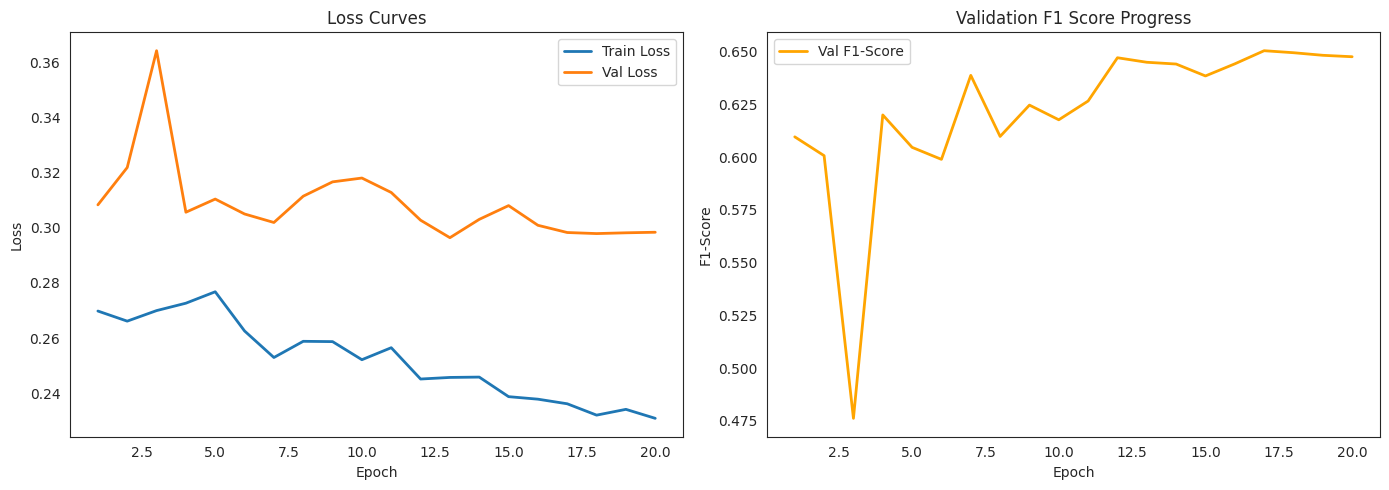

In [11]:
# Plot loss curves and F1 progress
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss", lw=2)
plt.plot(epochs_range, history["val_loss"], label="Val Loss", lw=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["val_f1"], label="Val F1-Score", color="orange", lw=2)
plt.xlabel("Epoch")
plt.ylabel("F1-Score")
plt.title("Validation F1 Score Progress")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_metrics_plots.png"), dpi=300)
plt.show()

In [ ]:
# TEST SET EVALUATION

best_model_path = os.path.join(OUTPUT_DIR, "best_siamese_model.pth")
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    print("Loaded best model weights for evaluation.")

test_loss, test_f1, test_prec, test_rec = validate(model, test_loader, criterion, DEVICE)

print("===========================================")
print(f"TEST SET EVALUATION RESULTS:")
print(f"Loss      : {test_loss:.4f}")
print(f"F1-Score  : {test_f1:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print("===========================================")

Loaded best model weights for evaluation.
TEST SET EVALUATION RESULTS:
Loss      : 0.2898
F1-Score  : 0.6395
Precision : 0.7072
Recall    : 0.5836



Validation Sample 1 (Dataset Index: 654)


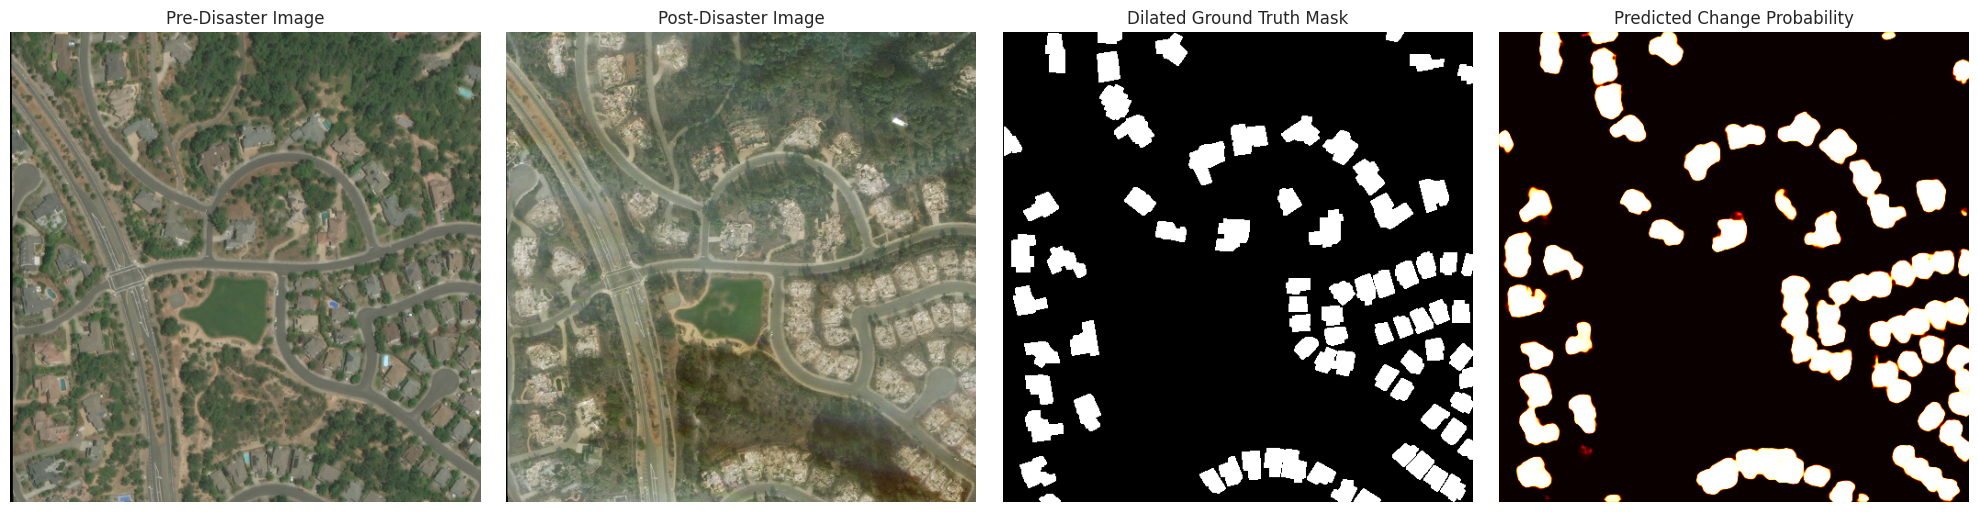


Validation Sample 2 (Dataset Index: 114)


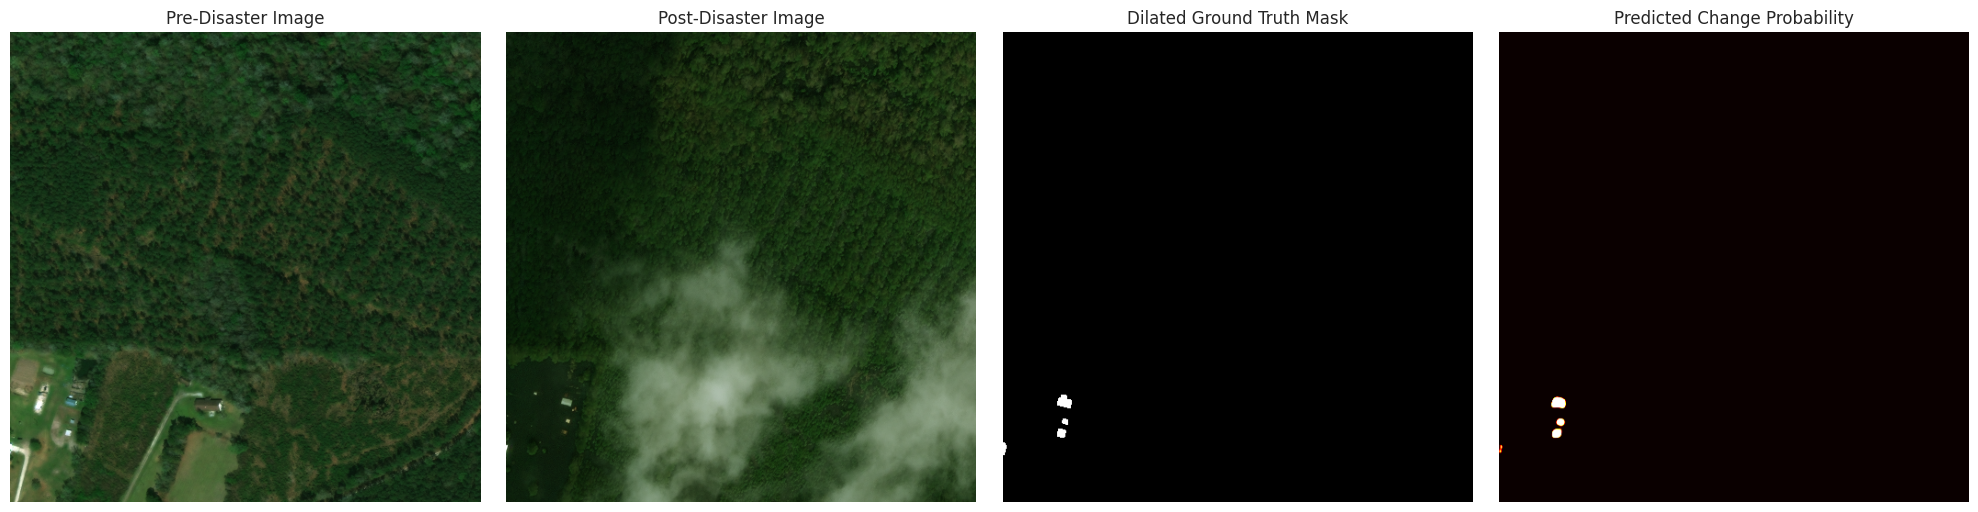


Validation Sample 3 (Dataset Index: 25)


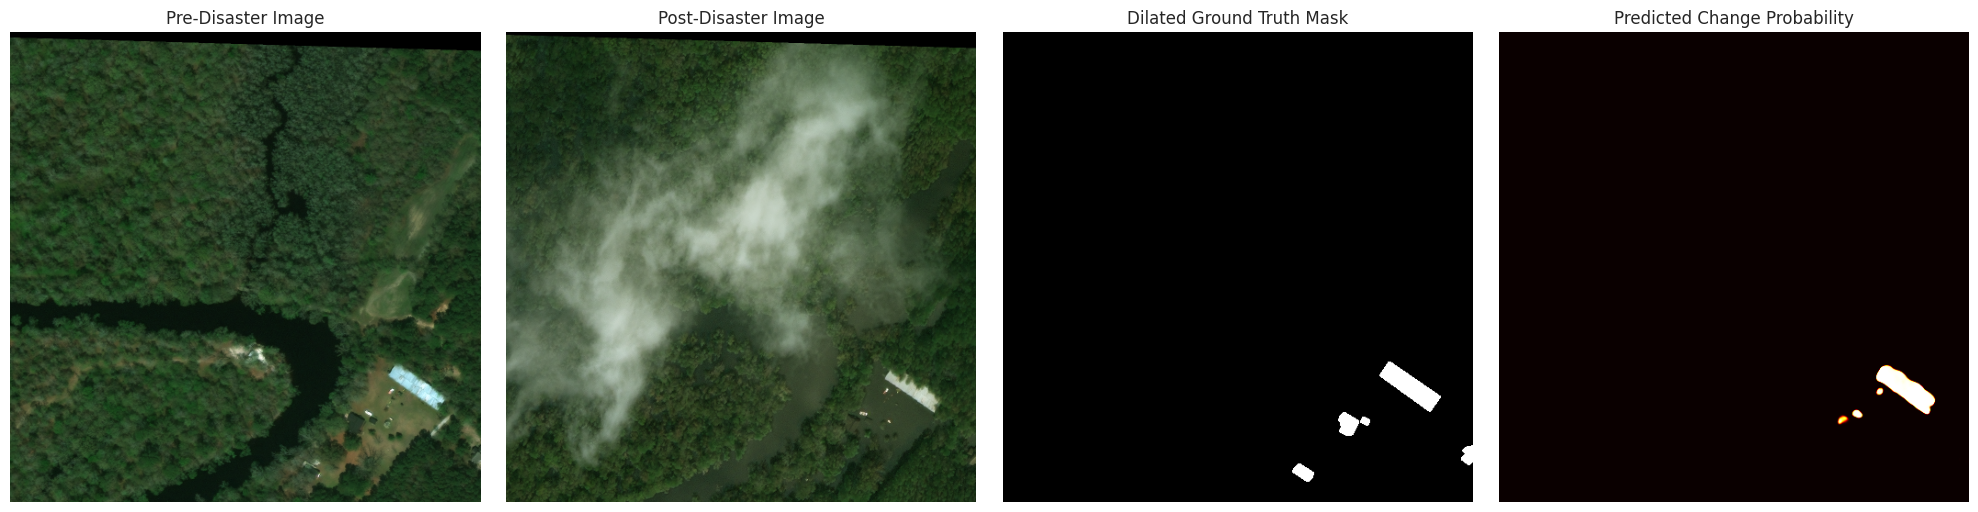

In [ ]:
def plot_prediction_panel(model, dataset, idx, device):
    model.eval()
    pre_tensor, post_tensor, mask_tensor = dataset[idx]
    
    # Get predicted logits and convert to probability mask
    with torch.no_grad():
        out = model(pre_tensor.unsqueeze(0).to(device), post_tensor.unsqueeze(0).to(device))
        pred_mask = torch.sigmoid(out).squeeze().cpu().numpy()
        
    # De-normalize tensors for plotting
    # Mean/std used: (0.485, 0.456, 0.406)
    def denormalize(img_t):
        img = img_t.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)
        return img
        
    pre_img = denormalize(pre_tensor)
    post_img = denormalize(post_tensor)
    gt_mask = mask_tensor.squeeze().numpy()
    
    # Plot Panel
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(pre_img)
    axes[0].set_title("Pre-Disaster Image")
    axes[0].axis("off")
    
    axes[1].imshow(post_img)
    axes[1].set_title("Post-Disaster Image")
    axes[1].axis("off")
    
    axes[2].imshow(gt_mask, cmap="gray")
    axes[2].set_title("Dilated Ground Truth Mask")
    axes[2].axis("off")
    
    axes[3].imshow(pred_mask, cmap="hot")
    axes[3].set_title("Predicted Change Probability")
    axes[3].axis("off")
    
    plt.tight_layout()
    plt.show()

# Plot 3 random validation examples
for i in range(3):
    idx = random.randint(0, len(val_dataset) - 1)
    print(f"\nValidation Sample {i+1} (Dataset Index: {idx})")
    plot_prediction_panel(model, val_dataset, idx, DEVICE)

In [ ]:
import shutil
import time

def generate_and_save_siamese_predictions(dataset, model, device, split_name):
    split_dir = os.path.join(OUTPUT_DIR, split_name)
    os.makedirs(split_dir, exist_ok=True)
    
    print(f"Generating predictions for {split_name} split ({len(dataset)} pairs)... ")
    model.eval()
    
    start_time = time.time()
    with torch.no_grad():
        for idx in range(len(dataset)):
            pre_tensor, post_tensor, _ = dataset[idx]
            
            # Add batch dimension and move to device
            pre_batch = pre_tensor.unsqueeze(0).to(device)
            post_batch = post_tensor.unsqueeze(0).to(device)
            
            # Predict
            outputs = model(pre_batch, post_batch)
            pred_mask = torch.sigmoid(outputs).squeeze().cpu().numpy()
            
            # Binarize with Otsu's thresholding
            pred_mask_uint8 = (pred_mask * 255).astype(np.uint8)
            _, thresh_mask = cv2.threshold(pred_mask_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            
            # Resize back to original 1024x1024 to match original coordinates
            pred_mask_1024 = cv2.resize(thresh_mask, (1024, 1024), interpolation=cv2.INTER_NEAREST)
            
            # Get event_id
            row = dataset.df.iloc[idx]
            event_id = row["event_id"]
            
            # Save PNG
            out_filename = f"{event_id}_change_pred.png"
            out_path = os.path.join(split_dir, out_filename)
            cv2.imwrite(out_path, pred_mask_1024)
            
            if (idx + 1) % 50 == 0 or (idx + 1) == len(dataset):
                elapsed = time.time() - start_time
                fps = (idx + 1) / elapsed
                print(f"Processed {idx+1}/{len(dataset)} | Elapsed: {elapsed:.1f}s | Speed: {fps:.1f} pairs/sec")

# Run prediction extraction on validation and test datasets
generate_and_save_siamese_predictions(val_dataset, model, DEVICE, "val")
generate_and_save_siamese_predictions(test_dataset, model, DEVICE, "test")

# Create a ZIP archive of the predictions
zip_archive_base = "change_detection_predictions"
print(f"\nCreating zip file: {zip_archive_base}.zip ...")
shutil.make_archive(zip_archive_base, 'zip', OUTPUT_DIR)
print("ZIP file successfully created! You can now download change_detection_predictions.zip from the output side panel in Kaggle.")

Generating predictions for val split (933 pairs)... 
Processed 50/933 | Elapsed: 12.4s | Speed: 4.0 pairs/sec
Processed 100/933 | Elapsed: 25.0s | Speed: 4.0 pairs/sec
Processed 150/933 | Elapsed: 37.2s | Speed: 4.0 pairs/sec
Processed 200/933 | Elapsed: 49.6s | Speed: 4.0 pairs/sec
Processed 250/933 | Elapsed: 62.6s | Speed: 4.0 pairs/sec
Processed 300/933 | Elapsed: 75.6s | Speed: 4.0 pairs/sec
Processed 350/933 | Elapsed: 88.6s | Speed: 3.9 pairs/sec
Processed 400/933 | Elapsed: 101.2s | Speed: 4.0 pairs/sec
Processed 450/933 | Elapsed: 114.1s | Speed: 3.9 pairs/sec
Processed 500/933 | Elapsed: 128.3s | Speed: 3.9 pairs/sec
Processed 550/933 | Elapsed: 140.5s | Speed: 3.9 pairs/sec
Processed 600/933 | Elapsed: 153.1s | Speed: 3.9 pairs/sec
Processed 650/933 | Elapsed: 165.5s | Speed: 3.9 pairs/sec
Processed 700/933 | Elapsed: 177.7s | Speed: 3.9 pairs/sec
Processed 750/933 | Elapsed: 190.3s | Speed: 3.9 pairs/sec
Processed 800/933 | Elapsed: 202.6s | Speed: 3.9 pairs/sec
Processed 8